Methira Binath Kahawita
w2119674

importing All the needed libraries

In [ ]:
# Import pandas for data handling
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import train_test_split to divide dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Import StandardScaler to normalize numeric features
from sklearn.preprocessing import StandardScaler

# Import LabelEncoder to convert categorical variables to numeric
from sklearn.preprocessing import LabelEncoder

# Import Logistic Regression classifier
from sklearn.linear_model import LogisticRegression

# Import K Nearest Neighbours classifier
from sklearn.neighbors import KNeighborsClassifier

# Import Naive Bayes classifier
from sklearn.naive_bayes import GaussianNB

# Import evaluation metrics
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay

# Import GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

loading the cleaned dataset

In [ ]:
# Load the cleaned dataset used for classification modelling
data_frame = pd.read_csv("/content/loan_approval_data_cleaned (1).csv")

# Display first rows to verify dataset
data_frame.head()

,id,age,income,home_ownership,employment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
0,19180,40.0,182004,3,3,1,35000,8.00,0.19,0,11,1,35000
1,28072,40.0,90000,0,3,2,35000,12.42,0.39,0,14,1,35000
2,32074,40.0,131004,0,9,5,30000,7.90,0.23,0,13,1,30000
3,7224,40.0,150000,0,9,0,25000,11.89,0.17,0,11,1,25000
4,14471,40.0,132000,0,3,2,25000,16.82,0.22,0,17,1,25000


creating label encoder to convert categorical variables in to  numeric values usimg the label encoder  

In [ ]:
# Create label encoder object
encoder = LabelEncoder()

# Convert home ownership category into numeric values
data_frame['home_ownership'] = encoder.fit_transform(data_frame['home_ownership'])

# Convert loan intent category into numeric values
data_frame['loan_intent'] = encoder.fit_transform(data_frame['loan_intent'])

# Convert payment default flag into numeric values
data_frame['payment_default_on_file'] = encoder.fit_transform(data_frame['payment_default_on_file'])

separating the data set in to input or else features(x) and the target varibales y  so first drop the unwanted

In [ ]:
# Define input features (X) by dropping the target and regression column
X = data_frame.drop(['loan_approval_status', 'max_allowed_loan'], axis=1)

# Define target variable (y)
y = data_frame['loan_approval_status']

# Display feature names used for modelling
print(X.columns)

# Show dataset shape
print(X.shape)

Index(['id', 'age', 'income', 'home_ownership', 'employment_length',
       'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio',
       'payment_default_on_file', 'credit_history_length'],
      dtype='object')
(58635, 11)


splitting  the dataset into training and testing
srtaify helps to emsure class distribution is all the same
the random state 42 means that te split willl be the same after every run time


In [ ]:
# Split the dataset into training and testing subsets
# 80% training and 20% testing
# Stratify ensures class distribution remains the same
# random_state ensures reproducibility

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

initialising the scaler object
fitting the scaler on traing data then tries to transform it
apply the same to test data


In [ ]:
# Create scaler object
scaler = StandardScaler()

# Fit scaler on training data and transform it
X_train = scaler.fit_transform(X_train)

# Apply same transformation to testing data
X_test = scaler.transform(X_test)

builidng the logistic regression model and initalising he logistic regression  model
traing the model
predicting the result on test data

In [ ]:
# Build Logistic Regression Model
# Create Logistic Regression model
lr_model = LogisticRegression()

# Train the model on training data
lr_model.fit(X_train, y_train)

# Predict loan approval on test data
lr_pred = lr_model.predict(X_test)

printing the logistic regression results

In [ ]:
# LR results
print(confusion_matrix(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

[[ 644 1026]
 [ 257 9800]]
              precision    recall  f1-score   support

           0       0.71      0.39      0.50      1670
           1       0.91      0.97      0.94     10057

    accuracy                           0.89     11727
   macro avg       0.81      0.68      0.72     11727
weighted avg       0.88      0.89      0.88     11727



Logistic regresion models roc curve

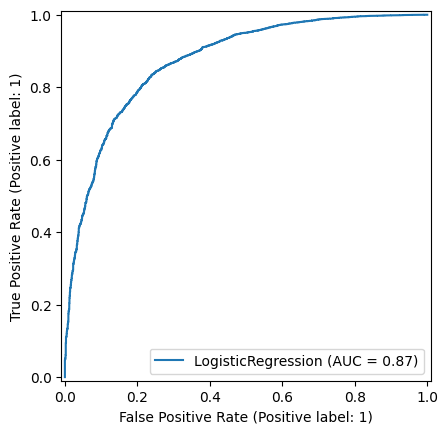

In [ ]:
RocCurveDisplay.from_estimator(lr_model, X_test, y_test)

intialising the naive bayes model
train the naive bayes model
predict on test data

In [ ]:
# Create Naive Bayes classifier
nb_model = GaussianNB()

# Train Naive Bayes model
nb_model.fit(X_train, y_train)

# Predict test data
nb_pred = nb_model.predict(X_test)

printing the naive  bayes results

In [ ]:
# NB results
print(confusion_matrix(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

[[1022  648]
 [1064 8993]]
              precision    recall  f1-score   support

           0       0.49      0.61      0.54      1670
           1       0.93      0.89      0.91     10057

    accuracy                           0.85     11727
   macro avg       0.71      0.75      0.73     11727
weighted avg       0.87      0.85      0.86     11727



getting the roc curve for naive bayes model

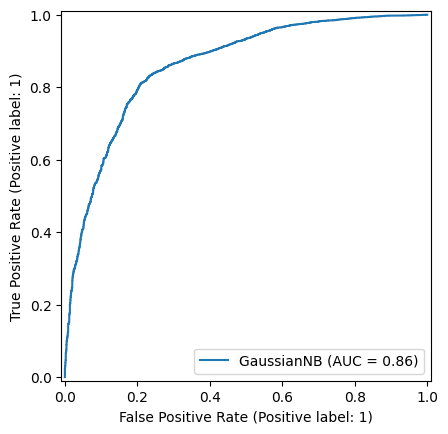

In [ ]:
RocCurveDisplay.from_estimator(nb_model, X_test, y_test)

voting classifier is a method  combining multiple models regarding ensamble learning

estimators means list of models you want combine
soft voting means each model gives probability to each class
like 70 percent for lr model 30 percent fornb model
ensemble_model.fit(X_train, y_train) this trains the ensemble model on train data
the next line use the trained ensemble model to predict the output for new data



In [ ]:
# Import VotingClassifier
from sklearn.ensemble import VotingClassifier

# Combine Logistic Regression and Naive Bayes
ensemble_model = VotingClassifier(
    estimators=[
        ('lr', lr_model),
        ('nb', nb_model)
    ],
    voting='soft'
)

# Train ensemble
ensemble_model.fit(X_train, y_train)

# Predict
ensemble_pred = ensemble_model.predict(X_test)

here importing classification report and and confusion matrix for evaluate the ensemble model
printing the confusion matrix
print(confusion_matrix(y_test, ensemble_pred))this compares actual values with the predicted values
print teh clasifictaion report this sompares actual values with the predicted values and print the calsification report



In [ ]:
# Evaluate ensemble
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, ensemble_pred))
print(classification_report(y_test, ensemble_pred))

[[ 918  752]
 [ 660 9397]]
              precision    recall  f1-score   support

           0       0.58      0.55      0.57      1670
           1       0.93      0.93      0.93     10057

    accuracy                           0.88     11727
   macro avg       0.75      0.74      0.75     11727
weighted avg       0.88      0.88      0.88     11727



drawing the auc roc graph  for the  ensemble model

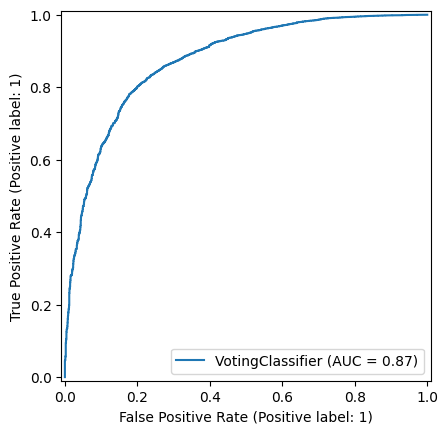

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(ensemble_model, X_test, y_test)

filters the data set to  only keep approved loans                                         

In [ ]:
# Only approved loans
reg_data = data_frame[data_frame['loan_approval_status'] == 1]

take columns on  regdata data set and drop the max allowed load column
out of the data set of approved loans and put it in the variable x reg


under target
take the dta set of aprioved loans slect te  the column max allowed loan and put it in y reg variable


In [ ]:
# Features
X_reg = reg_data.drop('max_allowed_loan', axis=1)

# Target
y_reg = reg_data['max_allowed_loan']

import the train test split test sixze is 20 percent
radom state = 42 is for reproducability to maintain the same exact train test split

In [ ]:
from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X_reg.columns)
print(X_reg.shape)

Index(['id', 'age', 'income', 'home_ownership', 'employment_length',
       'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio',
       'payment_default_on_file', 'credit_history_length',
       'loan_approval_status'],
      dtype='object')
(50286, 12)


import the deciion tree regressor
intilising the decision tre regressor
training the decision tree regressor
predict

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Fully grown tree
dt1 = DecisionTreeRegressor()

dt1.fit(X_train_reg, y_train_reg)

# Predict
y_pred_dt1 = dt1.predict(X_test_reg)

In [ ]:
# Pruned tree
dt2 = DecisionTreeRegressor(max_depth=4)

dt2.fit(X_train_reg, y_train_reg)

# Predict
y_pred_dt2 = dt2.predict(X_test_reg)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# DT1 results
print("DT1 MSE:", mean_squared_error(y_test_reg, y_pred_dt1))
print("DT1 MAE:", mean_absolute_error(y_test_reg, y_pred_dt1))
print("DT1 R2:", r2_score(y_test_reg, y_pred_dt1))

# DT2 results
print("DT2 MSE:", mean_squared_error(y_test_reg, y_pred_dt2))
print("DT2 MAE:", mean_absolute_error(y_test_reg, y_pred_dt2))
print("DT2 R2:", r2_score(y_test_reg, y_pred_dt2))

DT1 MSE: 73341324.80950487
DT1 MAE: 1304.7293696559952
DT1 R2: 0.9733944398481055
DT2 MSE: 379554693.7672907
DT2 MAE: 11327.627690760697
DT2 R2: 0.8623113877177899


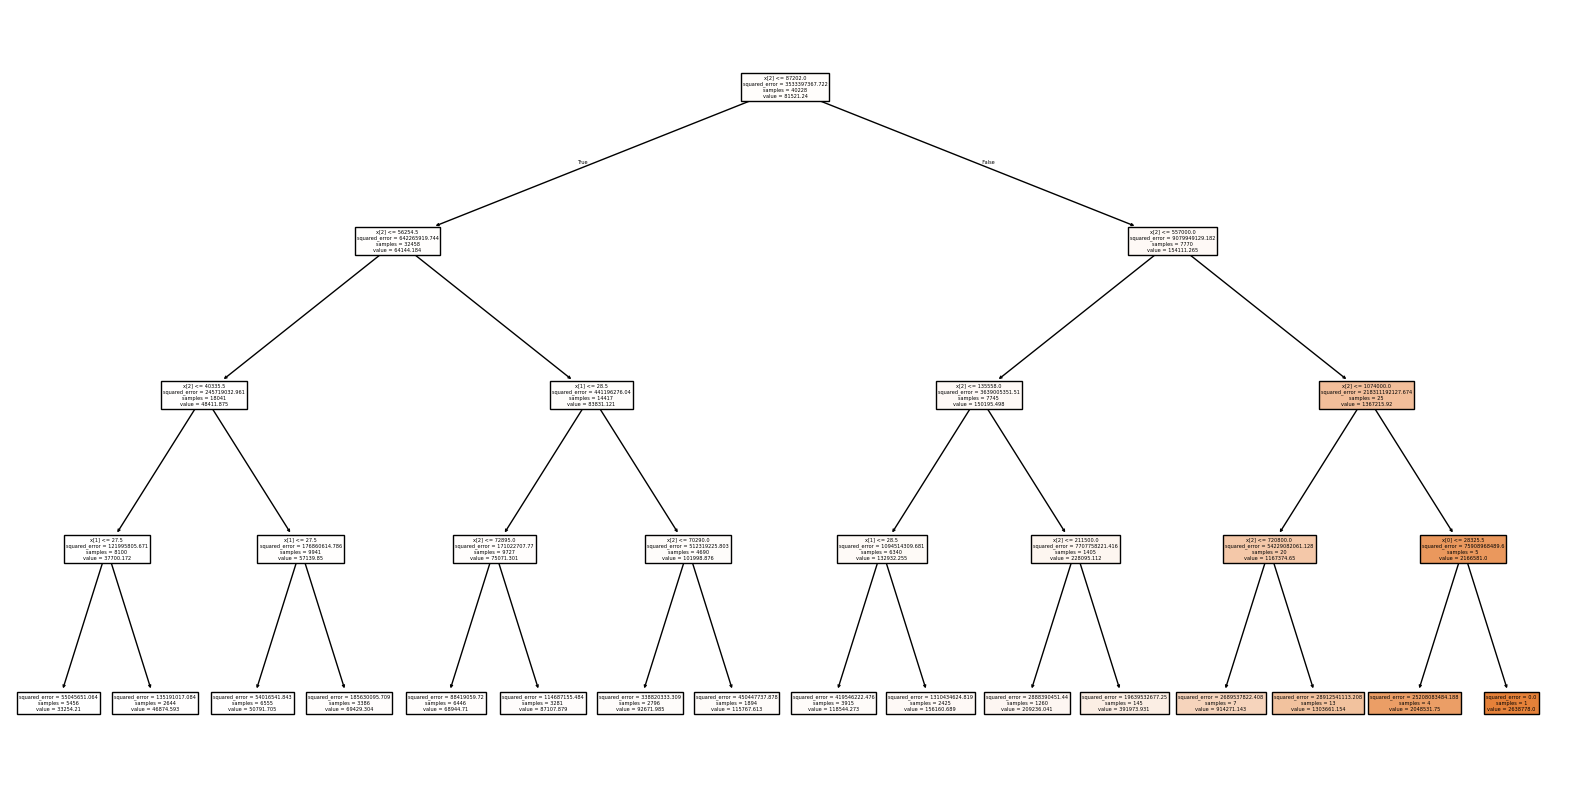

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(dt2, filled=True)
plt.show()

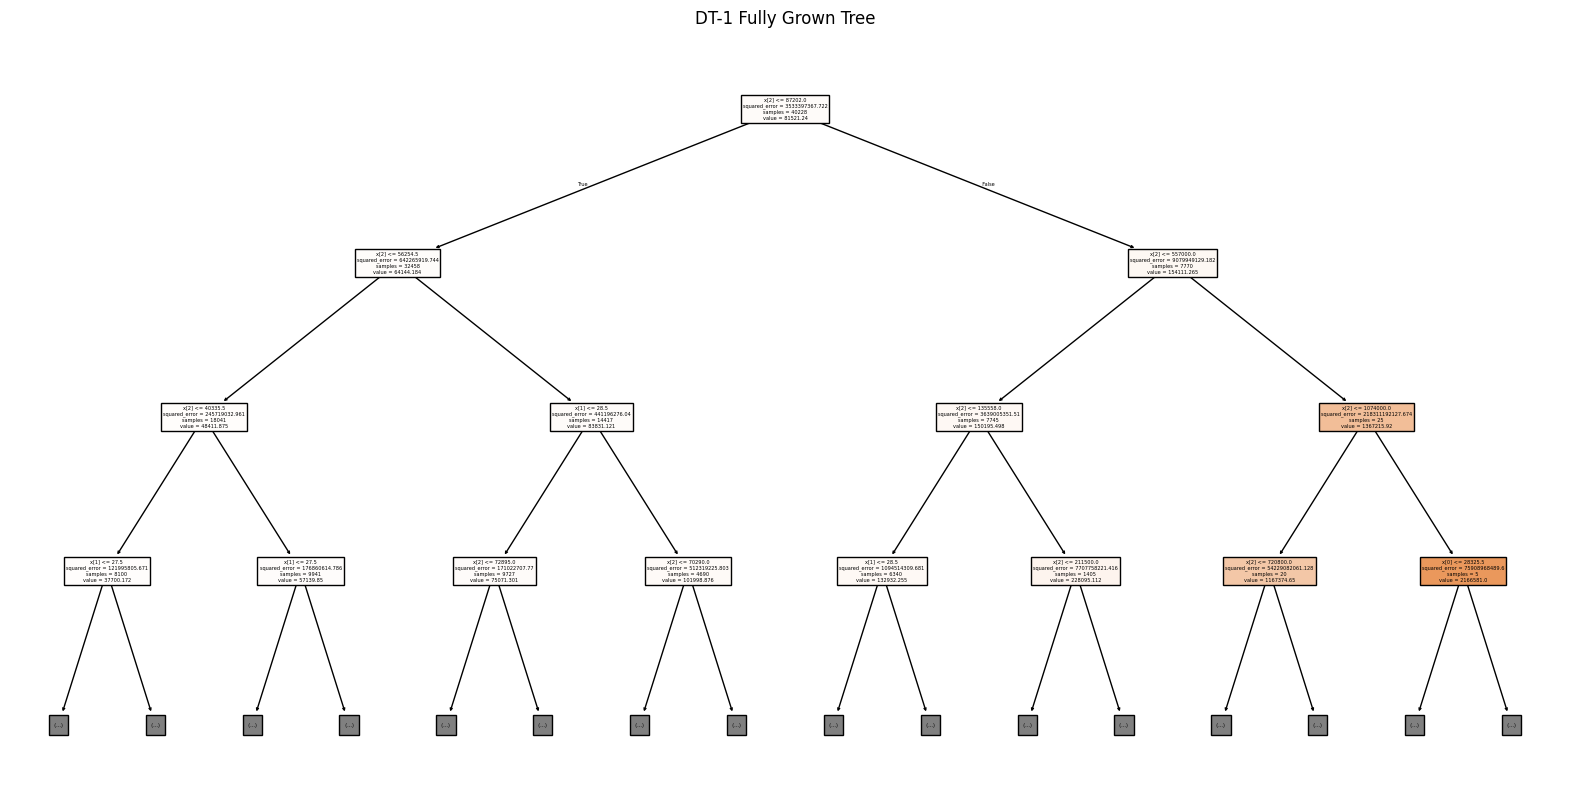

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(dt1, filled=True,max_depth=3)
plt.title("DT-1 Fully Grown Tree")
plt.show()

Applying the dt1 to the to Predict Maximum Loan Amount for a given customers data

In [ ]:
import pandas as pd

new_client = pd.DataFrame([{
    'id': 60256,
    'age': 56,
    'income': 57000,
    'home_ownership': 'Rent',
    'employment_length': 15,
    'loan_intent': 'Medical',
    'loan_amount': 25700,
    'loan_interest_rate': 23,
    'loan_income_ratio': 10,
    'payment_default_on_file': 'No',
    'credit_history_length': 35,
    'loan_approval_status': 1   # Approved = 1
}])

Encoding the text values to numbers as before

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

new_client['home_ownership'] = encoder.fit_transform(new_client['home_ownership'])
new_client['loan_intent'] = encoder.fit_transform(new_client['loan_intent'])
new_client['payment_default_on_file'] = encoder.fit_transform(new_client['payment_default_on_file'])

To ensure that the order matches

In [ ]:
new_client = new_client[X_reg.columns]

Predicting th outcome using DT1

In [ ]:
prediction = dt1.predict(new_client)

print("Predicted Maximum Loan Amount:", prediction[0])

Predicted Maximum Loan Amount: 83196.0
